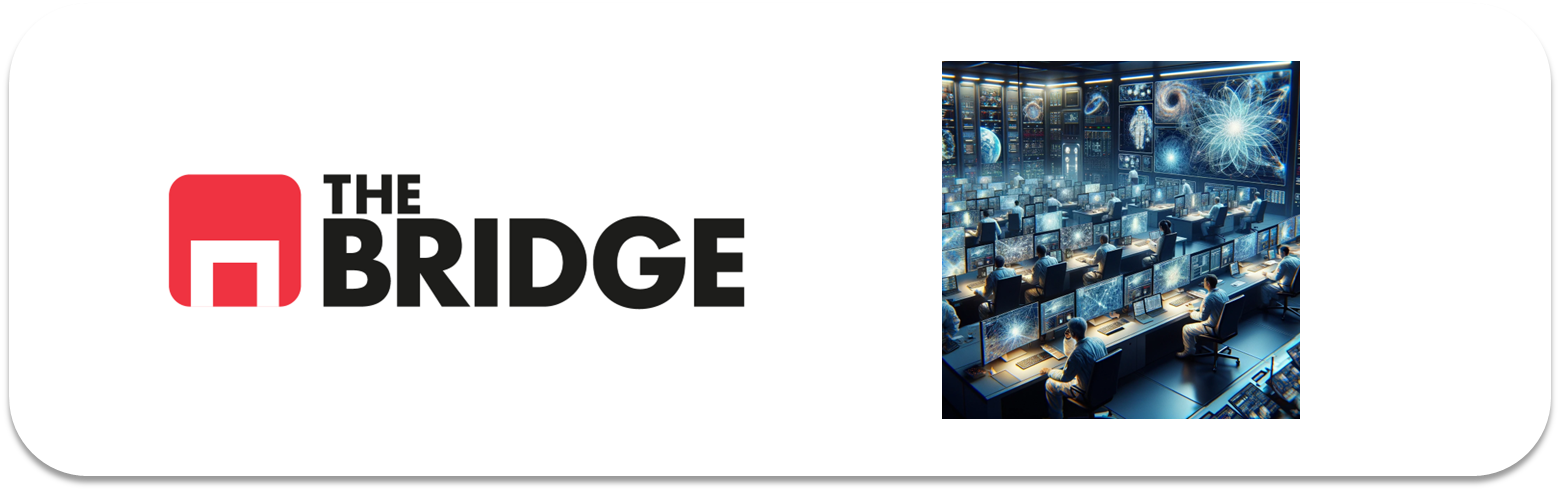

## PRACTICA OBLIGATORIA: **Transfer Learning y Fine Tuning con CNN**

* La práctica obligatoria de esta unidad consiste en un repetir el ejercicio de construcción de un modelo de clasificación de paisajes pero usando un modelo preentrenado. Descarga este notebook en tu ordenador y trabaja en local. Ten en cuenta que tendrás que descar los directorios de imágenes y datos adicionales, si los hubiera.
* Recuerda que debes subirla a tu repositorio personal antes de la sesión en vivo para que puntúe adecuadamente.  
* Recuerda también que no es necesario que esté perfecta, sólo es necesario que se vea el esfuerzo. 
* Esta práctica se resolverá en la sesión en vivo correspondiente y la solución se publicará en el repo del curso. 

### Ejercicio 0

Importa los paquetes y módulos que necesites a lo largo del notebook.

In [1]:
import cv2
import matplotlib.pyplot as plt
import numpy as np
import os
import pandas as pd
import tensorflow as tf

from skimage.io import imread
from sklearn.model_selection import train_test_split
from sklearn.utils import shuffle
from sklearn.metrics import classification_report, ConfusionMatrixDisplay

from tensorflow import keras
from tensorflow.keras.applications.mobilenet_v2 import MobileNetV2, decode_predictions, preprocess_input
from tensorflow.keras.preprocessing import image
from tensorflow.keras import datasets, layers, models

pd.options.mode.copy_on_write = True

### Objetivo del ejercicio

Comparar una red convolucional hecha ad-hoc frente a los modelos preentrenados y ajustados con fine tuning y transfer learning. Para ello emplea el dataset de paisajes del conjunto de ejercicios de la unidad anterior.


### Se pide

1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

4. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

5. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

6. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

EXTRA:
- Repetir el transfer learning empleando aumentado de imágenes.



1. Preparar los datos del modelo y las funciones de visualización, copia para ello todo lo que necesites de las soluciones del ejercicio de clasificación de paisajes de la unidad anterior.

In [2]:
ROOT_PATH = '../../Unidad_01_CNN_Redes_Convolucionales/02_Ejercicios_Workout/data/'
TRAIN_PATH = ROOT_PATH + "seg_train/"
TEST_PATH = ROOT_PATH + "seg_test/"

In [3]:
def read_data(directorio, reshape_dim = (32,32)):
    X = []
    y = []
    for folder in os.listdir(directorio):
        if os.path.isdir('/'.join([directorio, folder])):
            for file in os.listdir('/'.join([directorio, folder])):

                image = plt.imread('/'.join([directorio, folder, file]))
                image = cv2.resize(image, reshape_dim) # Redimensionamos las imágenes a 32x32

                X.append(image)
                y.append(folder)

    return np.array(X),np.array(y)

In [4]:
X_train, y_train = read_data(TRAIN_PATH, reshape_dim = (224, 224))

In [5]:
X_test, y_test = read_data(TEST_PATH, reshape_dim = (224, 224))

In [6]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(14034, 224, 224, 3)
(14034,)
(3000, 224, 224, 3)
(3000,)


In [7]:
class_names = ["buildings", "forest", "glacier", "mountain", "sea", "street"]
class_nums = [i for i in range(len(class_names))]

class_dicc = dict(zip(class_names, class_nums))
class_dicc

{'buildings': 0,
 'forest': 1,
 'glacier': 2,
 'mountain': 3,
 'sea': 4,
 'street': 5}

In [8]:
def show_images_batch(images, n_cols, labels=None):
    n_rows = ((len(images) - 1) // n_cols + 1)
    plt.figure(figsize=(n_cols * 2, n_rows * 2.2))

    for index, image in enumerate(images):
        plt.subplot(n_rows, n_cols, index + 1)
        plt.imshow(image)
        plt.axis("off")

        if labels is not None and index < len(labels):
            plt.title(str(labels[index]))

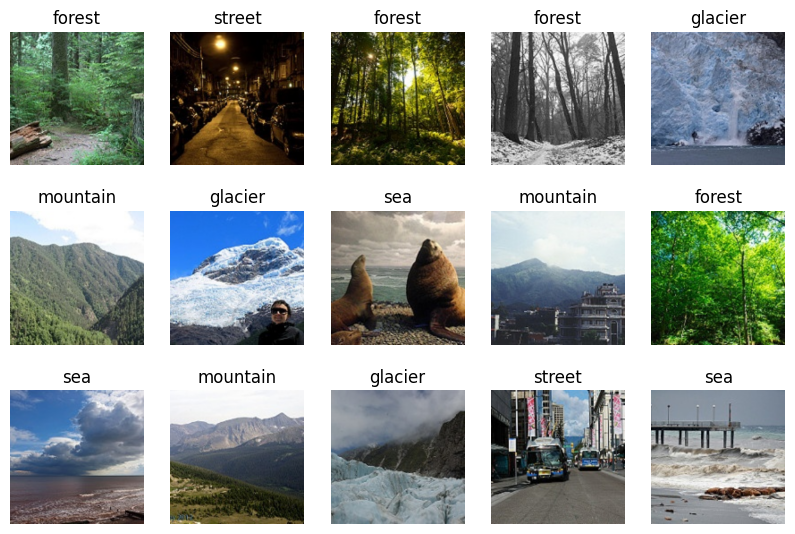

In [9]:
indices = np.random.randint(0, 14034, 15)
show_images_batch(X_train[indices], 5, y_train[indices])

In [10]:
pd.Series(y_train).value_counts(normalize = True)

mountain     0.178994
glacier      0.171298
street       0.169731
sea          0.162035
forest       0.161821
buildings    0.156121
Name: proportion, dtype: float64

Está balanceado

**Escalado**

In [11]:
# MobileNetV2 espera valores entre -1 y 1

X_train = X_train.astype("float32")/127.5 - 1
X_test = X_test.astype("float32")/127.5 - 1

In [12]:
X_train_shuffle, y_train_shuffle = shuffle(X_train, y_train, random_state= 42)

In [58]:
y_train_s_num = np.array([class_dicc[label] for label in y_train_shuffle])
y_train_s_num

array([0, 5, 5, ..., 2, 0, 3], shape=(14034,))

In [59]:
y_test_num = np.array([class_dicc[label] for label in y_test])
y_test_num

array([0, 0, 0, ..., 5, 5, 5], shape=(3000,))

2. Escoger entre uno de los modelos VGG-19, InceptionV3 y MobileNetV2 (todos en https://keras.io/api/applications/) (Se aconseja este último si no tenemos un ordenador muy potente). Si no te haces con estos puedes recurrir a la ResNetV50.

In [13]:
base_model_MN = MobileNetV2(input_shape = (224, 224, 3),
                             include_top = True,
                             weights = "imagenet",
                             classifier_activation = "softmax")

In [14]:
base_model_MN.summary()

Model: "mobilenetv2_1.00_224"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer[0][0] │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 3,538,984 (13.50 MB)

 Trainable params: 3,504,872 (13.37 MB)

 Non-trainable params: 34,112 (133.25 KB)

In [57]:
predictions = base_model_MN.predict(X_test)

94/94 ━━━━━━━━━━━━━━━━━━━━ 80s 849ms/step


3. Hacer un transfer-learning con una cabeza de como mucho 2 capas densas ocultas y una de salida. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

In [18]:
base_model_tl = MobileNetV2(input_shape = (224, 224, 3),
                             include_top = False,
                             weights = "imagenet")

In [19]:
# congelar las capas del MobileNetV2
for layer in base_model_tl.layers:
    layer.trainable = False

In [20]:
len(class_names)

6

In [21]:
capas = [
    base_model_tl,
    layers.Flatten(),
    layers.Dense(256, activation = "relu"),
    layers.Dense(64, activation = "relu"),
    layers.Dense(6, activation = "softmax")
]

model_tl = tf.keras.Sequential(capas)

In [22]:
model_tl.compile(optimizer = "adam",
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])

In [23]:
model_tl.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 62720)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    16,056,576 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │        16,448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 6)              │           390 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,331,398 (69.93 MB)

 Trainable params: 16,073,414 (61.32 MB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [26]:
early_stop = keras.callbacks.EarlyStopping(patience= 5, restore_best_weights = True)

history_tl = model_tl.fit(X_train_shuffle, y_train_s_num,
                          batch_size = 32,
                          epochs = 20,
                          validation_split = 0.2,
                          callbacks = [early_stop])

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 450s 1s/step - accuracy: 0.8643 - loss: 0.6672 - val_accuracy: 0.9059 - val_loss: 0.2972
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.9427 - loss: 0.1723 - val_accuracy: 0.9127 - val_loss: 0.2873
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 408s 1s/step - accuracy: 0.9710 - loss: 0.0885 - val_accuracy: 0.9102 - val_loss: 0.3975
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9806 - loss: 0.0587 - val_accuracy: 0.9173 - val_loss: 0.3773
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 407s 1s/step - accuracy: 0.9830 - loss: 0.0524 - val_accuracy: 0.9124 - val_loss: 0.4258
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 415s 1s/step - accuracy: 0.9754 - loss: 0.0813 - val_accuracy: 0.9102 - val_loss: 0.4377
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 420s 1s/step - accuracy: 0.9863 - loss: 0.0423 - val_accuracy: 0.9195 - val_loss: 0.4282


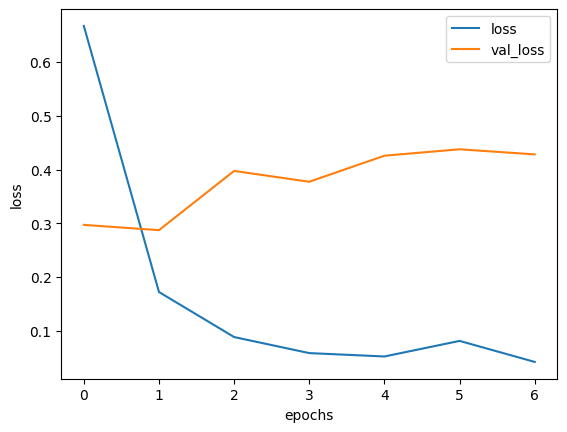

In [27]:
history_df_tl = pd.DataFrame(history_tl.history)
history_df_tl[["loss","val_loss"]].plot();
plt.xlabel("epochs")
plt.ylabel("loss");

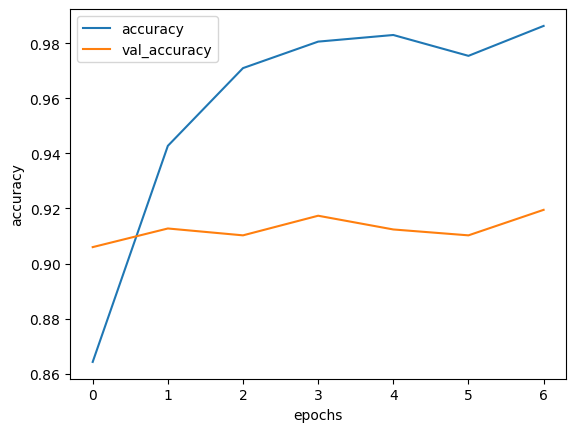

In [28]:
history_df_tl[["accuracy","val_accuracy"]].plot();
plt.xlabel("epochs")
plt.ylabel("accuracy");

In [29]:
model_tl.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 75s 793ms/step - accuracy: 0.8963 - loss: 0.3309


[0.33090871572494507, 0.8963333368301392]

In [30]:
y_pred = [np.argmax(prediction) for prediction in  model_tl.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 81s 837ms/step


In [31]:
print(classification_report(y_test_num, y_pred))

              precision    recall  f1-score   support

           0       0.97      0.82      0.89       437
           1       0.99      0.97      0.98       474
           2       0.92      0.74      0.82       553
           3       0.78      0.91      0.84       525
           4       0.91      0.96      0.93       510
           5       0.86      0.98      0.92       501

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.90      3000
weighted avg       0.90      0.90      0.90      3000



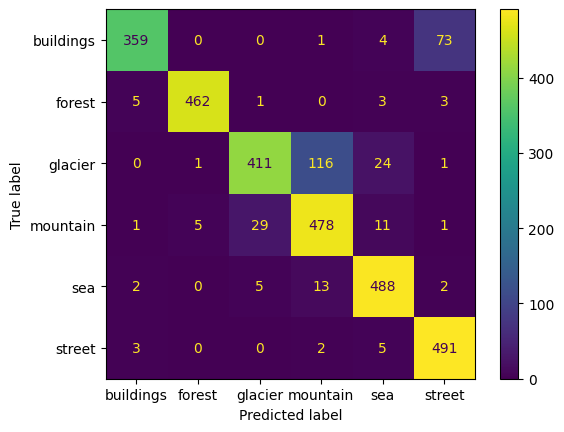

In [33]:
ConfusionMatrixDisplay.from_predictions(y_test_num, y_pred, display_labels = class_names)

- Confunde edificios con calles
- Confunde glaciares con montañas y un poco con imágenes del mar
- Confunde montañas con glaciares o con el mar

In [34]:
model_tl.save("model_tl.keras")

4. Hacer un fine-tuning con la misma cabeza diseñada en el punto anterior. Mostrar la evaluación contra test, el report de clasificación y la matriz de confusión.

In [40]:
base_model_tl.trainable = True

In [42]:
model_tl.compile(optimizer = "adam",
              loss = "sparse_categorical_crossentropy",
              metrics = ["accuracy"])

In [44]:
history_ft = model_tl.fit(X_train_shuffle, y_train_s_num,
                          batch_size = 32,
                          epochs = 20,
                          validation_split = 0.2,
                          callbacks = [early_stop])

Epoch 1/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 457s 1s/step - accuracy: 0.9336 - loss: 0.2148 - val_accuracy: 0.8839 - val_loss: 0.4422
Epoch 2/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 412s 1s/step - accuracy: 0.9632 - loss: 0.1207 - val_accuracy: 0.9027 - val_loss: 0.3741
Epoch 3/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 419s 1s/step - accuracy: 0.9774 - loss: 0.0678 - val_accuracy: 0.8978 - val_loss: 0.4815
Epoch 4/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 417s 1s/step - accuracy: 0.9835 - loss: 0.0511 - val_accuracy: 0.9116 - val_loss: 0.3940
Epoch 5/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 392s 1s/step - accuracy: 0.9898 - loss: 0.0344 - val_accuracy: 0.9206 - val_loss: 0.4922
Epoch 6/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 413s 1s/step - accuracy: 0.9885 - loss: 0.0408 - val_accuracy: 0.9188 - val_loss: 0.4731
Epoch 7/20
351/351 ━━━━━━━━━━━━━━━━━━━━ 404s 1s/step - accuracy: 0.9908 - loss: 0.0279 - val_accuracy: 0.9099 - val_loss: 0.5444


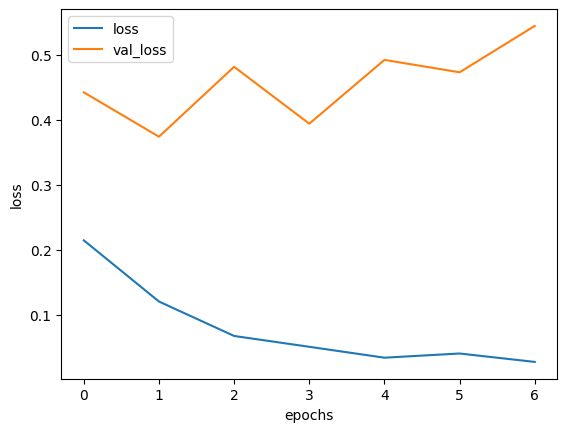

In [45]:
history_df_ft = pd.DataFrame(history_ft.history)
history_df_ft[["loss","val_loss"]].plot();
plt.xlabel("epochs")
plt.ylabel("loss");

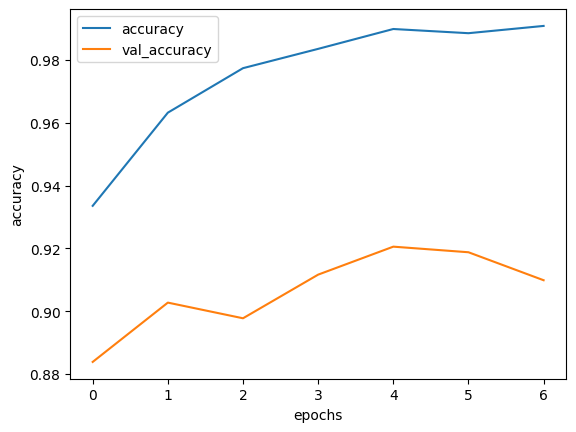

In [46]:
history_df_ft[["accuracy","val_accuracy"]].plot();
plt.xlabel("epochs")
plt.ylabel("accuracy");

In [47]:
model_tl.evaluate(X_test, y_test_num)

94/94 ━━━━━━━━━━━━━━━━━━━━ 73s 780ms/step - accuracy: 0.9027 - loss: 0.3368


[0.3367916941642761, 0.9026666879653931]

In [48]:
y_pred = [np.argmax(prediction) for prediction in  model_tl.predict(X_test)]

94/94 ━━━━━━━━━━━━━━━━━━━━ 79s 783ms/step


In [49]:
print(classification_report(y_test_num, y_pred))

              precision    recall  f1-score   support

           0       0.92      0.91      0.92       437
           1       0.99      0.99      0.99       474
           2       0.76      0.92      0.83       553
           3       0.93      0.72      0.81       525
           4       0.95      0.96      0.95       510
           5       0.93      0.93      0.93       501

    accuracy                           0.90      3000
   macro avg       0.91      0.90      0.91      3000
weighted avg       0.91      0.90      0.90      3000



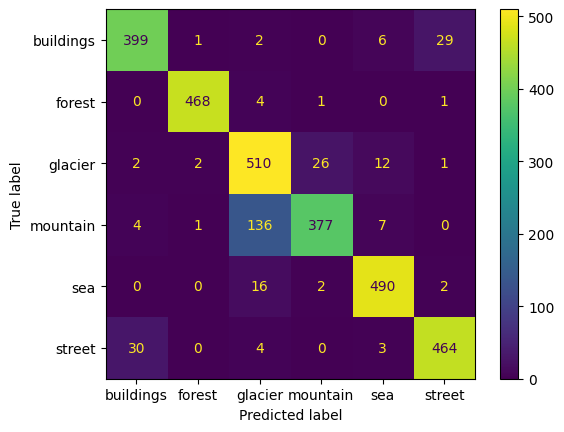

In [50]:
ConfusionMatrixDisplay.from_predictions(y_test_num, y_pred, display_labels = class_names)

In [51]:
model_tl.save("model_ft.keras")

5. Comparar los resultados con los obtenidos con la red convolucional del ejercicio mencionado.

In [ ]:
print(classification_report(y_test_numeric, y_pred))

              precision    recall  f1-score   support

           0       0.77      0.65      0.70       437
           1       0.87      0.94      0.90       474
           2       0.74      0.62      0.67       553
           3       0.76      0.68      0.72       525
           4       0.61      0.81      0.69       510
           5       0.82      0.81      0.81       501

    accuracy                           0.75      3000
   macro avg       0.76      0.75      0.75      3000
weighted avg       0.76      0.75      0.75      3000



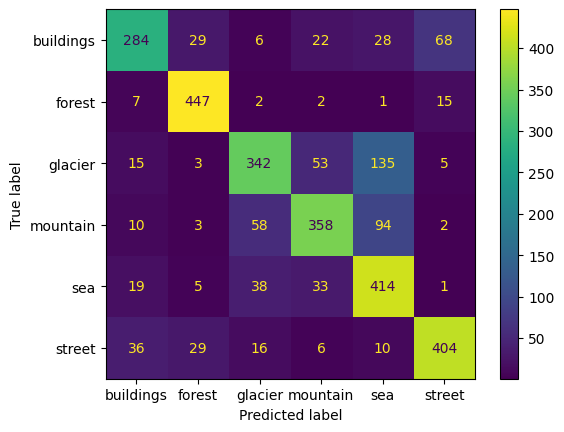

In [ ]:
ConfusionMatrixDisplay.from_predictions(y_test_numeric, y_pred, display_labels = class_names)

Bastante peor con redes convolucionales